In [1]:
#You might need to install this
!python -m pip install git+https://github.com/afeinstein20/stella/

  Cloning https://github.com/afeinstein20/stella/ to /tmp/pip-req-build-8nj04p4a
  Running command git clone --filter=blob:none --quiet https://github.com/afeinstein20/stella/ /tmp/pip-req-build-8nj04p4a
  Resolved https://github.com/afeinstein20/stella/ to commit 05c5e4bf5814385e91aa902e069841e94b1925a0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os, sys, tensorflow as tf, keras, h5py

2026-04-07 22:27:02.348658: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-07 22:27:04.091519: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
print(tf.__version__, keras.__version__, h5py.__version__)


2.16.1 3.13.2 3.14.0


In [4]:
import stella

/home/yangz2/anaconda3/envs/space/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [5]:
import numpy as np
from tqdm import tqdm_notebook
import matplotlib.pyplot as plt

In [6]:
plt.rcParams['font.size'] = 20

In [7]:
#ds = stella.DownloadSets()
#ds.download_models()

In [8]:
OUT_DIR='./results/'

In [9]:
mycnn=stella.ConvNN(output_dir=OUT_DIR)

Can only use stella.ConvNN.predict().


/home/yangz2/anaconda3/envs/space/lib/python3.11/site-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 5 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


<class 'astropy.time.core.Time'>


/tmp/ipykernel_1990855/3594454295.py:4: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lc.download().PDCSAP_FLUX


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

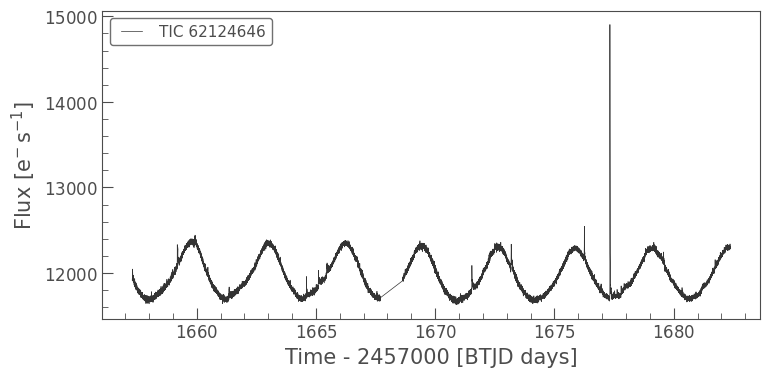

In [10]:
from lightkurve.search import search_lightcurve

lc = search_lightcurve(target='tic62124646', mission='TESS',sector=13)
lc = lc.download().PDCSAP_FLUX
print(type(lc.time))
lc.plot()

In [12]:
# ===== 使用 keras 模型进行预测 =====
import numpy as np

# 加载转换好的 keras 模型
model = keras.models.load_model("./results/ensemble_s0015_i0200_b0.6.h5")

# 数据预处理（与 stella 相同的方式）
def preprocess_flare(times, fluxes, errs, cadences=128):
    """预处理光变曲线数据，与 stella 库保持一致"""
    # 归一化：用 flux 除以中位数
    lc = fluxes / np.nanmedian(fluxes)
    err = errs + 0.0
    
    # 去除 NaN
    mask = np.isfinite(times) & np.isfinite(lc)
    time = times[mask]
    lc = lc[mask]
    err = err[mask]
    
    cad_pad = cadences // 2
    
    # 识别间隙
    diff = np.diff(time)
    med, std = np.nanmedian(diff), np.nanstd(diff)
    bad = np.where(np.abs(diff) >= med + 1.5*std)[0]
    
    # 标记需要跳过的索引
    bad_inds = np.arange(0, cad_pad, 1, dtype=int)
    bad_inds = np.append(bad_inds, np.arange(len(time) - cad_pad, len(time), 1, dtype=int))
    for b in bad:
        bad_inds = np.append(bad_inds, np.arange(b - cad_pad, b + cad_pad, 1, dtype=int))
    bad_inds = np.sort(np.unique(bad_inds))
    
    # 所有可用索引
    all_inds = np.arange(0, len(time), 1, dtype=int)
    good_inds = np.delete(all_inds, bad_inds)
    
    # 构建输入数据
    reshaped_data = np.zeros((len(lc), cadences))
    for i in good_inds:
        loc = [int(i - cad_pad), int(i + cad_pad)]
        f = lc[loc[0]:loc[1]]
        reshaped_data[i] = f
    
    # reshape 为 (n, cadences, 1)
    reshaped_data = reshaped_data.reshape(reshaped_data.shape[0], reshaped_data.shape[1], 1)
    
    # 批量预测
    predictions = model.predict(reshaped_data, verbose=0).flatten()
    
    return time, lc, predictions, good_inds

# 预处理数据
t, f, pred, good_inds = preprocess_flare(lc.time.value, lc.flux.value, lc.flux_err.value)

# 过滤掉无效数据点
t = t[good_inds]
f = f[good_inds]
pred = pred[good_inds]

print(f"预测完成，共 {len(pred)} 个样本")

2026-04-07 22:28:27.409668: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13164 MB memory:  -> device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0000:18:00.0, compute capability: 7.0
2026-04-07 22:28:27.410400: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 10340 MB memory:  -> device: 1, name: Tesla V100-PCIE-16GB, pci bus id: 0000:3b:00.0, compute capability: 7.0
2026-04-07 22:28:27.411037: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 10828 MB memory:  -> device: 2, name: Tesla V100-PCIE-16GB, pci bus id: 0000:86:00.0, compute capability: 7.0
2026-04-07 22:28:27.411584: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 13644 MB memory:  -> device: 3, name: Tesla V100-PCIE-16GB, pci bus id

预测完成，共 16510 个样本


In [13]:
# ===== 将 h5 模型转换为 keras 格式 =====
h5_path = "./results/ensemble_s0015_i0200_b0.6.h5"
keras_path = "./results/ensemble_s0015_i0200_b0.6.keras"

# 重新构建模型结构
model_conversion = keras.Sequential([
    keras.layers.Input(shape=(128, 1)),  # cadences=128

    # Local pattern extraction
    keras.layers.Conv1D(filters=16, kernel_size=7, padding='same', activation='relu'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Dropout(0.1),

    keras.layers.Conv1D(filters=32, kernel_size=5, padding='same', activation='relu'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Dropout(0.1),

    # Temporal aggregation
    keras.layers.GRU(32, return_sequences=False, dropout=0.1, recurrent_dropout=0.0),

    # Classifier
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(1, activation='sigmoid')
])

# 加载h5权重前先构建模型
model_conversion.build(input_shape=(None, 128, 1))

# 加载h5权重
model_conversion.load_weights(h5_path)

# 保存为keras格式
model_conversion.save(keras_path)
print(f"模型已成功转换为keras格式: {keras_path}")

模型已成功转换为keras格式: ./results/ensemble_s0015_i0200_b0.6.keras


In [14]:
# 查看模型结构
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 16)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,147 (39.64 KB)

 Trainable params: 10,145 (39.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

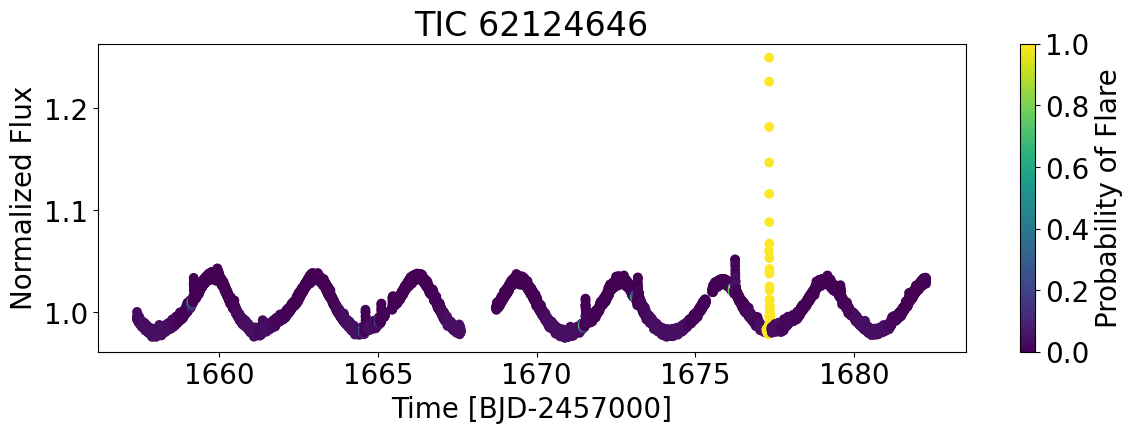

In [15]:
# 绘制预测结果
plt.figure(figsize=(14,4))
plt.scatter(t, f, c=pred, vmin=0, vmax=1)
plt.colorbar(label='Probability of Flare')
plt.xlabel('Time [BJD-2457000]')
plt.ylabel('Normalized Flux')
plt.title('TIC {}'.format(lc.targetid))
plt.show()